# kloppy × StatsBomb Open Data Demo
示範如何用 kloppy 將 `mix/data` 的 StatsBomb JSON 壓平成標準 DataFrame

---
## Part 1 — mix 裡有什麼資料？

In [2]:
import json, os, pandas as pd

BASE = "/Users/mouyasushi/Desktop/fifa/mix/data"

with open(f"{BASE}/competitions.json") as f:
    comps = json.load(f)

comp_map = {
    (str(c["competition_id"]), str(c["season_id"])): (
        c["competition_name"], c["country_name"], c["season_name"]
    ) for c in comps
}

rows = []
for comp_id in sorted(os.listdir(f"{BASE}/matches")):
    comp_path = f"{BASE}/matches/{comp_id}"
    if not os.path.isdir(comp_path):
        continue
    for season_file in sorted(os.listdir(comp_path)):
        season_id = season_file.replace(".json", "")
        with open(f"{comp_path}/{season_file}") as f:
            matches = json.load(f)
        info = comp_map.get((comp_id, season_id), ("Unknown", "Unknown", "Unknown"))
        dates = sorted(m["match_date"] for m in matches)
        rows.append({
            "competition": info[0],
            "country":     info[1],
            "season":      info[2],
            "matches":     len(matches),
            "date_from":   dates[0],
            "date_to":     dates[-1],
        })

overview_df = pd.DataFrame(rows).sort_values(["competition", "season"]).reset_index(drop=True)
print(f"總共 {len(overview_df)} 個賽季，{overview_df['matches'].sum():,} 場比賽")
overview_df

總共 80 個賽季，3,961 場比賽


,competition,country,season,matches,date_from,date_to
0,1. Bundesliga,Germany,2015/2016,34,2015-08-15,2016-05-14
1,1. Bundesliga,Germany,2023/2024,34,2023-08-19,2024-05-18
2,African Cup of Nations,Africa,2023,52,2024-01-13,2024-02-11
3,Champions League,Europe,1970/1971,1,1971-06-02,1971-06-02
4,Champions League,Europe,1971/1972,1,1972-05-31,1972-05-31
...,...,...,...,...,...,...
75,UEFA Europa League,Europe,1988/1989,3,1989-03-15,1989-05-03
76,UEFA Women's Euro,Europe,2022,31,2022-07-06,2022-07-31
77,UEFA Women's Euro,Europe,2025,31,2025-07-02,2025-07-27
78,Women's World Cup,International,2019,52,2019-06-07,2019-07-07


In [4]:
overview_df['competition'].unique()

<StringArray>
[          '1. Bundesliga',  'African Cup of Nations',
        'Champions League',            'Copa America',
            'Copa del Rey', 'FA Women's Super League',
      'FIFA U20 World Cup',          'FIFA World Cup',
       'Frauen Bundesliga',     'Indian Super league',
                 'La Liga',                  'Liga F',
        'Liga Profesional',                 'Ligue 1',
     'Major League Soccer',                    'NWSL',
   'North American League',          'Premier League',
                 'Serie A',           'Serie A Women',
               'UEFA Euro',      'UEFA Europa League',
       'UEFA Women's Euro',       'Women's World Cup']
Length: 24, dtype: str

In [5]:
overview_df[overview_df['competition'] == 'FIFA World Cup']

,competition,country,season,matches,date_from,date_to
30,FIFA World Cup,International,1958,2,1958-06-24,1958-06-29
31,FIFA World Cup,International,1962,1,1962-05-30,1962-05-30
32,FIFA World Cup,International,1970,6,1970-06-03,1970-06-21
33,FIFA World Cup,International,1974,6,1974-06-19,1974-07-07
34,FIFA World Cup,International,1986,3,1986-06-22,1986-06-29
35,FIFA World Cup,International,1990,1,1990-06-24,1990-06-24
36,FIFA World Cup,International,2018,64,2018-06-14,2018-07-15
37,FIFA World Cup,International,2022,64,2022-11-20,2022-12-18


---
## Part 2 — 選一場比賽，用 kloppy 載入並壓平

In [6]:
import warnings
warnings.filterwarnings("ignore")

from kloppy import statsbomb

# FIFA World Cup 2018 決賽 (match_id = 8658)
# 從本地 mix 資料夾載入
MATCH_ID = 8658

dataset = statsbomb.load(
    event_data=f"{BASE}/events/{MATCH_ID}.json",
    lineup_data=f"{BASE}/lineups/{MATCH_ID}.json",
)

print(f"載入成功：{len(dataset)} 個事件")
print(f"座標系統：{dataset.metadata.coordinate_system}")
print(f"球場大小：{dataset.metadata.pitch_dimensions}")

載入成功：3036 個事件
座標系統：<kloppy.domain.models.common.KloppyCoordinateSystem object at 0x1099dd410>
球場大小：NormalizedPitchDimensions(x_dim=Dimension(min=0, max=1), y_dim=Dimension(min=0, max=1), standardized=True, unit=<Unit.NORMED: 'normed'>, goal_width=0.10764705882352942, goal_height=2.44, six_yard_width=0.26941176470588235, six_yard_length=0.05238095238095238, penalty_area_width=0.5929411764705882, penalty_area_length=0.15714285714285714, circle_radius=0.08714285714285715, corner_radius=0.009523809523809525, penalty_spot_distance=0.10476190476190476, penalty_arc_radius=0.08714285714285715, pitch_length=105, pitch_width=68)


Q: 請跟我解釋以下所有 col 的 meaning

A:

| 欄位 | 說明 |
|------|------|
| `event_id` | 事件唯一識別碼（UUID） |
| `event_type` | 事件類型（PASS / SHOT / CARRY / DUEL...） |
| `period_id` | 上下半場（1=上半場, 2=下半場, 3/4=延長賽） |
| `timestamp` | 事件發生的比賽時間（從該節開始計算的 timedelta） |
| `end_timestamp` | 事件結束時間（持續性動作如 CARRY 才有值） |
| `ball_state` | 球的狀態：`alive`（比賽進行中）/ `dead`（停球） |
| `ball_owning_team` | 當下持球隊伍 ID |
| `team_id` | 執行此事件的隊伍 ID |
| `player_id` | 執行此事件的球員 ID |
| `receiver_player_id` | 接球球員 ID（PASS 事件才有值） |
| `coordinates_x` | 事件發生位置的 X 座標（0~1 正規化，×105 換算公尺） |
| `coordinates_y` | 事件發生位置的 Y 座標（0~1 正規化，×68 換算公尺） |
| `end_coordinates_x` | 動作結束位置的 X（傳球落點、射門落點等） |
| `end_coordinates_y` | 動作結束位置的 Y |
| `result` | 動作結果（SHOT: GOAL/SAVED/BLOCKED/OFF_TARGET；PASS: SUCCESS/INCOMPLETE；DUEL: WON/LOST...） |
| `success` | True/False，result 的布林版本 |
| `set_piece_type` | 定位球類型：CORNER / FREE_KICK / GOAL_KICK / THROW_IN / KICK_OFF / PENALTY（非定位球為 null） |
| `body_part_type` | 使用身體部位：RIGHT_FOOT / LEFT_FOOT / HEAD（無接觸事件為 null） |
| `pass_type` | 傳球類型：CROSS / THROUGH_BALL / SWITCH 等（僅 PASS 事件） |
| `duel_type` | 對抗類型：TACKLE（滑鏟）/ AERIAL（頭球爭頂）等（僅 DUEL 事件） |
| `goalkeeper_type` | 門將動作類型（僅 GOALKEEPER 事件） |
| `is_under_pressure` | True 表示執行動作時受到對手逼搶 |
| `is_counter_attack` | True 表示此事件發生在反擊序列中 |
| `card_type` | 牌的顏色：YELLOW / RED（僅 CARD 事件） |

In [8]:
# 壓平成 DataFrame（所有欄位）
df = dataset.to_df()

print(f"Shape: {df.shape}")
for col in df.columns:
    print(f"  {col}")

Shape: (3036, 24)
  event_id
  event_type
  period_id
  timestamp
  end_timestamp
  ball_state
  ball_owning_team
  team_id
  player_id
  coordinates_x
  coordinates_y
  result
  success
  end_coordinates_x
  end_coordinates_y
  receiver_player_id
  set_piece_type
  body_part_type
  is_under_pressure
  pass_type
  duel_type
  goalkeeper_type
  is_counter_attack
  card_type


In [11]:
# 前 10 筆事件預覽
key_cols = [
    "event_type", "period_id", "timestamp",
    "team_id", "player_id",
    "coordinates_x", "coordinates_y",
    "result", "success"
]
df[key_cols].dropna(subset=["player_id"]).head(10)

,event_type,period_id,timestamp,team_id,player_id,coordinates_x,coordinates_y,result,success
4,PASS,1,0 days 00:00:00.400000,785,5472,0.504357,0.506728,COMPLETE,True
5,GENERIC:Ball Receipt*,1,0 days 00:00:01.559000,785,5469,0.408912,0.520184,NaN,None
6,CARRY,1,0 days 00:00:01.559000,785,5469,0.408912,0.520184,COMPLETE,True
7,PASS,1,0 days 00:00:02.347000,785,5469,0.401020,0.506728,COMPLETE,True
8,PRESSURE,1,0 days 00:00:02.919000,771,3604,0.582786,0.385515,NaN,None
9,GENERIC:Ball Receipt*,1,0 days 00:00:03.120000,785,5463,0.361565,0.641446,NaN,None
10,CARRY,1,0 days 00:00:03.120000,785,5463,0.361565,0.641446,COMPLETE,True
11,PASS,1,0 days 00:00:03.947000,785,5463,0.353673,0.708848,COMPLETE,True
12,GENERIC:Ball Receipt*,1,0 days 00:00:05.200000,785,5461,0.345782,0.983039,NaN,None
13,CARRY,1,0 days 00:00:05.200000,785,5461,0.345782,0.983039,COMPLETE,True


---
## Part 3 — 事件類型分佈

Q: 請看文檔解釋下方 event type 的不同 meaning

A:

**核心動作事件**

| event_type | 說明 |
|------------|------|
| `PASS` | 傳球。包含短傳、長傳、橫傳、直塞、角球開球等。有 `pass_type`、`receiver_player_id`、`end_coordinates` |
| `CARRY` | 帶球跑動（持球移動但未傳球）。`end_coordinates` 為帶球終點 |
| `SHOT` | 射門。有 `result`（GOAL/SAVED/BLOCKED/OFF_TARGET/POST）和射門落點座標 |
| `DUEL` | 爭搶對抗：地面搶球（TACKLE）或空中爭頂（AERIAL）|
| `TAKE_ON` | 過人嘗試（帶球突破對手），`result` 為 COMPLETE 或 INCOMPLETE |
| `CLEARANCE` | 解圍，防守球員將球踢離危險區域 |
| `INTERCEPTION` | 攔截傳球，切斷對方的傳球路線 |
| `GOALKEEPER` | 門將專屬動作（撲救、接球、出擊等），有 `goalkeeper_type` |

**失誤/丟球事件**

| event_type | 說明 |
|------------|------|
| `RECOVERY` | 搶得鬆散球（loose ball），通常在爭搶或失誤後 |
| `MISCONTROL` | 控球失誤，球員接球或停球時失去控制 |
| `FOUL_COMMITTED` | 犯規，有 `card_type` 若伴隨出牌 |
| `BALL_OUT` | 球出界（邊線球、底線球），比賽暫停 |

**流程控制事件**

| event_type | 說明 |
|------------|------|
| `SUBSTITUTION` | 換人，有換入/換出球員資訊 |
| `FORMATION_CHANGE` | 陣型變換 |
| `CARD` | 出牌事件，有 `card_type`（YELLOW/RED） |
| `PLAYER_ON` / `PLAYER_OFF` | 球員上/下場（換人的配對事件） |

**GENERIC:* 系列（StatsBomb 原始事件，kloppy 未完整映射）**

| event_type | 說明 |
|------------|------|
| `GENERIC:Ball Receipt*` | 成功接球（收到傳球後的確認事件，與 PASS 成對出現） |
| `GENERIC:Starting XI` | 比賽開始時的先發名單快照 |
| `GENERIC:Half Start` / `GENERIC:Half End` | 各節開始/結束標記 |
| `GENERIC:Block` | 攔截射門或傳球（用身體阻擋） |
| `GENERIC:Dispossessed` | 被對手搶走球 |
| `GENERIC:Foul Won` | 被犯規（贏得犯規的一方） |
| `GENERIC:Goal Keeper` | 早期版本門將事件（同 GOALKEEPER） |
| `GENERIC:Dribbled Past` | 被過人（對應 TAKE_ON 的防守方視角） |
| `GENERIC:Shield` | 護球（用身體擋住對手搶球） |
| `GENERIC:Injury Stoppage` | 因傷停賽中斷 |
| `GENERIC:Camera On/off` | 攝影機標記（資料採集用，非球場事件） |
| `GENERIC:Error` | 資料標注錯誤標記 |
| `GENERIC:Referee Ball-Drop` | 裁判球（雙方爭搶後由裁判丟球重新開始） |

**事件之間的關聯**：許多事件成對出現，例如 PASS → GENERIC:Ball Receipt*（傳球 + 接球），TAKE_ON → GENERIC:Dribbled Past（過人 + 被過人），FOUL_COMMITTED → GENERIC:Foul Won（犯規 + 被犯規）。可透過 `related_events`（原始 JSON）連結。

In [5]:
event_counts = df["event_type"].value_counts().reset_index()
event_counts.columns = ["event_type", "count"]
event_counts

,event_type,count
0,PASS,846
1,GENERIC:Ball Receipt*,747
2,CARRY,617
3,PRESSURE,254
4,RECOVERY,82
5,DUEL,75
6,BALL_OUT,40
7,CLEARANCE,37
8,GENERIC:Camera On,34
9,MISCONTROL,33


---
## Part 4 — 取出 Shot 事件（含 xG）

In [12]:
shots = df[df["event_type"] == "SHOT"].copy()

shot_cols = [
    "period_id", "timestamp", "team_id", "player_id",
    "coordinates_x", "coordinates_y",
    "end_coordinates_x", "end_coordinates_y",
    "result", "body_part_type"
]
print(f"Shot events：{len(shots)}")
shots[shot_cols]

Shot events：24


,period_id,timestamp,team_id,player_id,coordinates_x,coordinates_y,end_coordinates_x,end_coordinates_y,result,body_part_type
689,1,0 days 00:17:56.987000,785,5472,0.065476,0.520184,NaN,NaN,OWN_GOAL,NaN
736,1,0 days 00:20:51.227000,785,5468,0.925794,0.614485,0.986905,0.453577,OFF_TARGET,HEAD
807,1,0 days 00:23:34.907000,785,5470,0.890873,0.345074,0.995635,0.600331,OFF_TARGET,LEFT_FOOT
930,1,0 days 00:27:53.880000,785,5474,0.864683,0.385515,0.995635,0.547768,GOAL,LEFT_FOOT
1079,1,0 days 00:37:56.787000,771,5487,0.890873,0.493272,0.995635,0.467033,GOAL,LEFT_FOOT
1103,1,0 days 00:39:25.267000,785,5465,0.890873,0.506728,0.960714,0.506728,OFF_TARGET,LEFT_FOOT
1226,1,0 days 00:42:47.027000,785,5474,0.969444,0.412475,0.951984,0.425956,BLOCKED,HEAD
1231,1,0 days 00:42:50.027000,785,3471,0.934524,0.304632,0.934524,0.345074,BLOCKED,RIGHT_FOOT
1261,1,0 days 00:45:17.307000,785,5468,0.951984,0.493272,0.995635,0.592243,OFF_TARGET,HEAD
1439,2,0 days 00:01:10.027000,771,5487,0.780476,0.560564,0.986905,0.484526,SAVED,LEFT_FOOT


---
## Part 5 — 取出 Pass 事件

In [13]:
passes = df[df["event_type"] == "PASS"].copy()

pass_cols = [
    "period_id", "timestamp", "team_id", "player_id",
    "coordinates_x", "coordinates_y",
    "end_coordinates_x", "end_coordinates_y",
    "result", "pass_type", "body_part_type"
]
print(f"Pass events:{len(passes)}")
passes[pass_cols].head(15)

Pass events:846


,period_id,timestamp,team_id,player_id,coordinates_x,coordinates_y,end_coordinates_x,end_coordinates_y,result,pass_type,body_part_type
4,1,0 days 00:00:00.400000,785,5472,0.504357,0.506728,0.408912,0.520184,COMPLETE,NaN,RIGHT_FOOT
7,1,0 days 00:00:02.347000,785,5469,0.401020,0.506728,0.361565,0.641446,COMPLETE,NaN,RIGHT_FOOT
11,1,0 days 00:00:03.947000,785,5463,0.353673,0.708848,0.345782,0.983039,COMPLETE,NaN,RIGHT_FOOT
15,1,0 days 00:00:06.240000,785,5461,0.314218,0.971732,0.082937,0.614485,COMPLETE,LONG_BALL,RIGHT_FOOT
20,1,0 days 00:00:09.400000,785,3444,0.074206,0.614485,0.606871,0.560564,INCOMPLETE,LONG_BALL,RIGHT_FOOT
24,1,0 days 00:00:13.627000,771,5485,0.393129,0.627966,0.393129,0.762770,INCOMPLETE,HIGH_PASS,NaN
25,1,0 days 00:00:16.680000,785,5474,0.606871,0.237230,0.504357,0.291152,COMPLETE,NaN,RIGHT_FOOT
29,1,0 days 00:00:19.360000,785,5470,0.495643,0.197876,0.565357,0.016961,COMPLETE,NaN,LEFT_FOOT
32,1,0 days 00:00:20.120000,785,5457,0.574071,0.016961,0.539214,0.318113,COMPLETE,NaN,RIGHT_FOOT
36,1,0 days 00:00:23.547000,785,5469,0.574071,0.277672,0.547929,0.250711,COMPLETE,NaN,RIGHT_FOOT


---
## Part 6 — 座標視覺化：射門位置圖

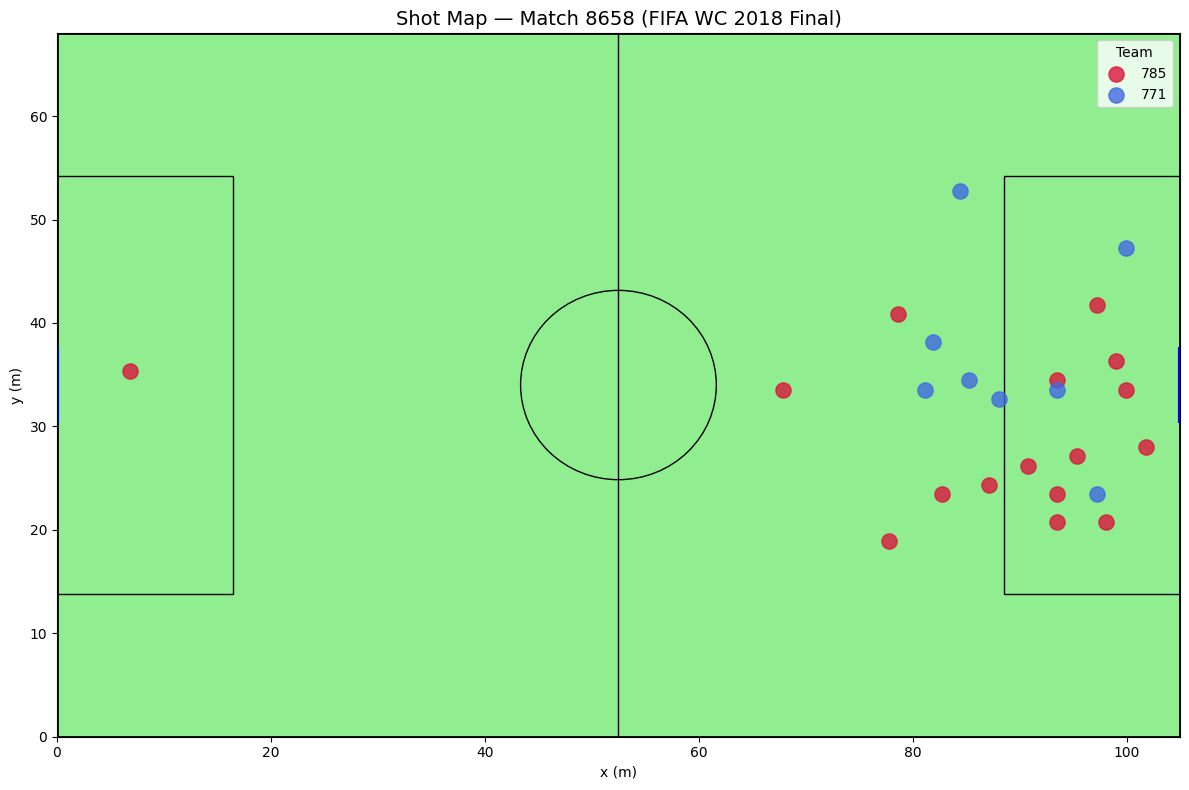

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_xlim(0, 105)
ax.set_ylim(0, 68)
ax.add_patch(patches.Rectangle((0, 0), 105, 68, fill=False, edgecolor="black", lw=2))
ax.plot([52.5, 52.5], [0, 68], color="black", lw=1)
ax.add_patch(patches.Circle((52.5, 34), 9.15, fill=False, edgecolor="black", lw=1))
ax.add_patch(patches.Rectangle((0, 13.84), 16.5, 40.32, fill=False, edgecolor="black", lw=1))
ax.add_patch(patches.Rectangle((88.5, 13.84), 16.5, 40.32, fill=False, edgecolor="black", lw=1))
ax.add_patch(patches.Rectangle((0, 30.34), 0, 7.32, fill=False, edgecolor="blue", lw=3))
ax.add_patch(patches.Rectangle((105, 30.34), 0, 7.32, fill=False, edgecolor="blue", lw=3))

# Bug fix: 座標從 0~1 正規化還原回公尺
shots["x_m"] = shots["coordinates_x"] * 105
shots["y_m"] = shots["coordinates_y"] * 68

teams = shots["team_id"].dropna().unique()
colors = ["crimson", "royalblue"]

for team, color in zip(teams, colors):
    team_shots = shots[shots["team_id"] == team]
    ax.scatter(
        team_shots["x_m"],
        team_shots["y_m"],
        c=color, s=120, alpha=0.8,
        label=str(team), zorder=5
    )

ax.set_title(f"Shot Map — Match {MATCH_ID} (FIFA WC 2018 Final)", fontsize=14)
ax.legend(title="Team")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_facecolor("#90EE90")
plt.tight_layout()
plt.show()

---
## Part 7 — 批次壓平：一個賽季所有比賽

In [15]:
# FIFA World Cup 2018 所有 64 場 → 合併成單一 DataFrame
import warnings
warnings.filterwarnings("ignore")

WC2018_COMP_ID = "43"
WC2018_SEASON_ID = "3"

with open(f"{BASE}/matches/{WC2018_COMP_ID}/{WC2018_SEASON_ID}.json") as f:
    wc_matches = json.load(f)

all_events = []
for i, m in enumerate(wc_matches):
    mid = m["match_id"]
    event_path  = f"{BASE}/events/{mid}.json"
    lineup_path = f"{BASE}/lineups/{mid}.json"
    if not os.path.exists(event_path):
        continue
    ds = statsbomb.load(event_data=event_path, lineup_data=lineup_path)
    tmp = ds.to_df()
    tmp["match_id"]   = mid
    tmp["match_date"] = m["match_date"]
    tmp["home_team"]  = m["home_team"]["home_team_name"]
    tmp["away_team"]  = m["away_team"]["away_team_name"]
    all_events.append(tmp)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(wc_matches)} games...")

wc2018_df = pd.concat(all_events, ignore_index=True)
print(f"\nFIFA WC 2018 完整事件資料：{wc2018_df.shape}")
wc2018_df.head()

  10/64 games...
  20/64 games...
  30/64 games...
  40/64 games...
  50/64 games...
  60/64 games...

FIFA WC 2018 完整事件資料：(232245, 28)


,event_id,event_type,period_id,timestamp,end_timestamp,ball_state,ball_owning_team,team_id,player_id,coordinates_x,...,is_under_pressure,duel_type,pass_type,goalkeeper_type,card_type,is_counter_attack,match_id,match_date,home_team,away_team
0,bf86711b-77f5-4a77-a475-4a8d04d92c95,GENERIC:Starting XI,1,0 days 00:00:00,NaT,alive,781,781,NaN,NaN,...,None,NaN,NaN,NaN,NaN,None,8650,2018-07-06,Brazil,Belgium
1,9dee71fc-d07a-42ff-b449-ad1b50dcb78a,GENERIC:Starting XI,1,0 days 00:00:00,NaT,alive,781,782,NaN,NaN,...,None,NaN,NaN,NaN,NaN,None,8650,2018-07-06,Brazil,Belgium
2,98d8a4de-e5c0-4b72-9281-14b427abbe42,GENERIC:Half Start,1,0 days 00:00:00,NaT,alive,781,781,NaN,NaN,...,None,NaN,NaN,NaN,NaN,None,8650,2018-07-06,Brazil,Belgium
3,b2e9bc80-5920-4510-ba6e-a23f654b7cad,GENERIC:Half Start,1,0 days 00:00:00,NaT,alive,781,782,NaN,NaN,...,None,NaN,NaN,NaN,NaN,None,8650,2018-07-06,Brazil,Belgium
4,007431ef-b210-4e34-a994-10dc91df7578,PASS,1,0 days 00:00:00.340000,0 days 00:00:01.513000,alive,781,781,4320,0.495643,...,None,NaN,NaN,NaN,NaN,None,8650,2018-07-06,Brazil,Belgium


In [16]:
# 各隊射門數 & 進球數
wc_shots = wc2018_df[wc2018_df["event_type"] == "SHOT"]
summary = (
    wc_shots.groupby("team_id")
    .agg(
        total_shots=("event_type", "count"),
        goals=("result", lambda x: (x == "GOAL").sum()),
    )
    .sort_values("total_shots", ascending=False)
    .reset_index()
)
summary

,team_id,total_shots,goals
0,785,125,20
1,782,108,15
2,781,104,8
3,768,101,16
4,771,82,12
5,772,77,9
6,770,73,2
7,794,63,3
8,783,63,6
9,796,61,17
